In [6]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


In [2]:
def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

In [3]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}

dset_map = {
    'newcastle_left': 'Newcastle',
    'newcastle_right': 'Newcastle',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
}
dset_order_nomap = ['newcastle', 'stages', 'dreamt', 'tbi']
dset_order = ['Newcastle', 'STAGES', 'DREAMT', 'TBI']

In [11]:
## Subject-wise performance metrics
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)

cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
soft_preds_all = []
targets_all = []
preds_all = []

macro_results = defaultdict(list)
summary_diffs = defaultdict(list)
summary_means = defaultdict(list)
exp_i = []
subject_i = []
dataset_i = []

# exp1_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_internal/'
# exp2_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal/'

exp1_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_tp/tp_1.0'
exp2_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tp/tp_1.0'

experiments = [('LSTM-C', exp1_path), ('Linear', exp2_path)]
for exp_name, experiment_dir in experiments:
    for dataset in os.scandir(experiment_dir):
        for sub_dir in os.scandir(dataset):
            subject_i.append(os.path.basename(sub_dir))
            dataset_i.append(os.path.basename(dataset))
            exp_i.append(exp_name)

            missing_idx = ss_label_map['missing']

            scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

            scores = scores[targets != missing_idx]
            targets = targets[targets != missing_idx]
            
            soft_preds_all.append(scores)
            targets_all.append(targets)
            
            # Get hard predictions
            preds = scores.argmax(axis=-1)
            preds_all.append(preds)

            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)

            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[ss_label_map_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['AUC'].append(np.nanmean(cw_auc))

macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)


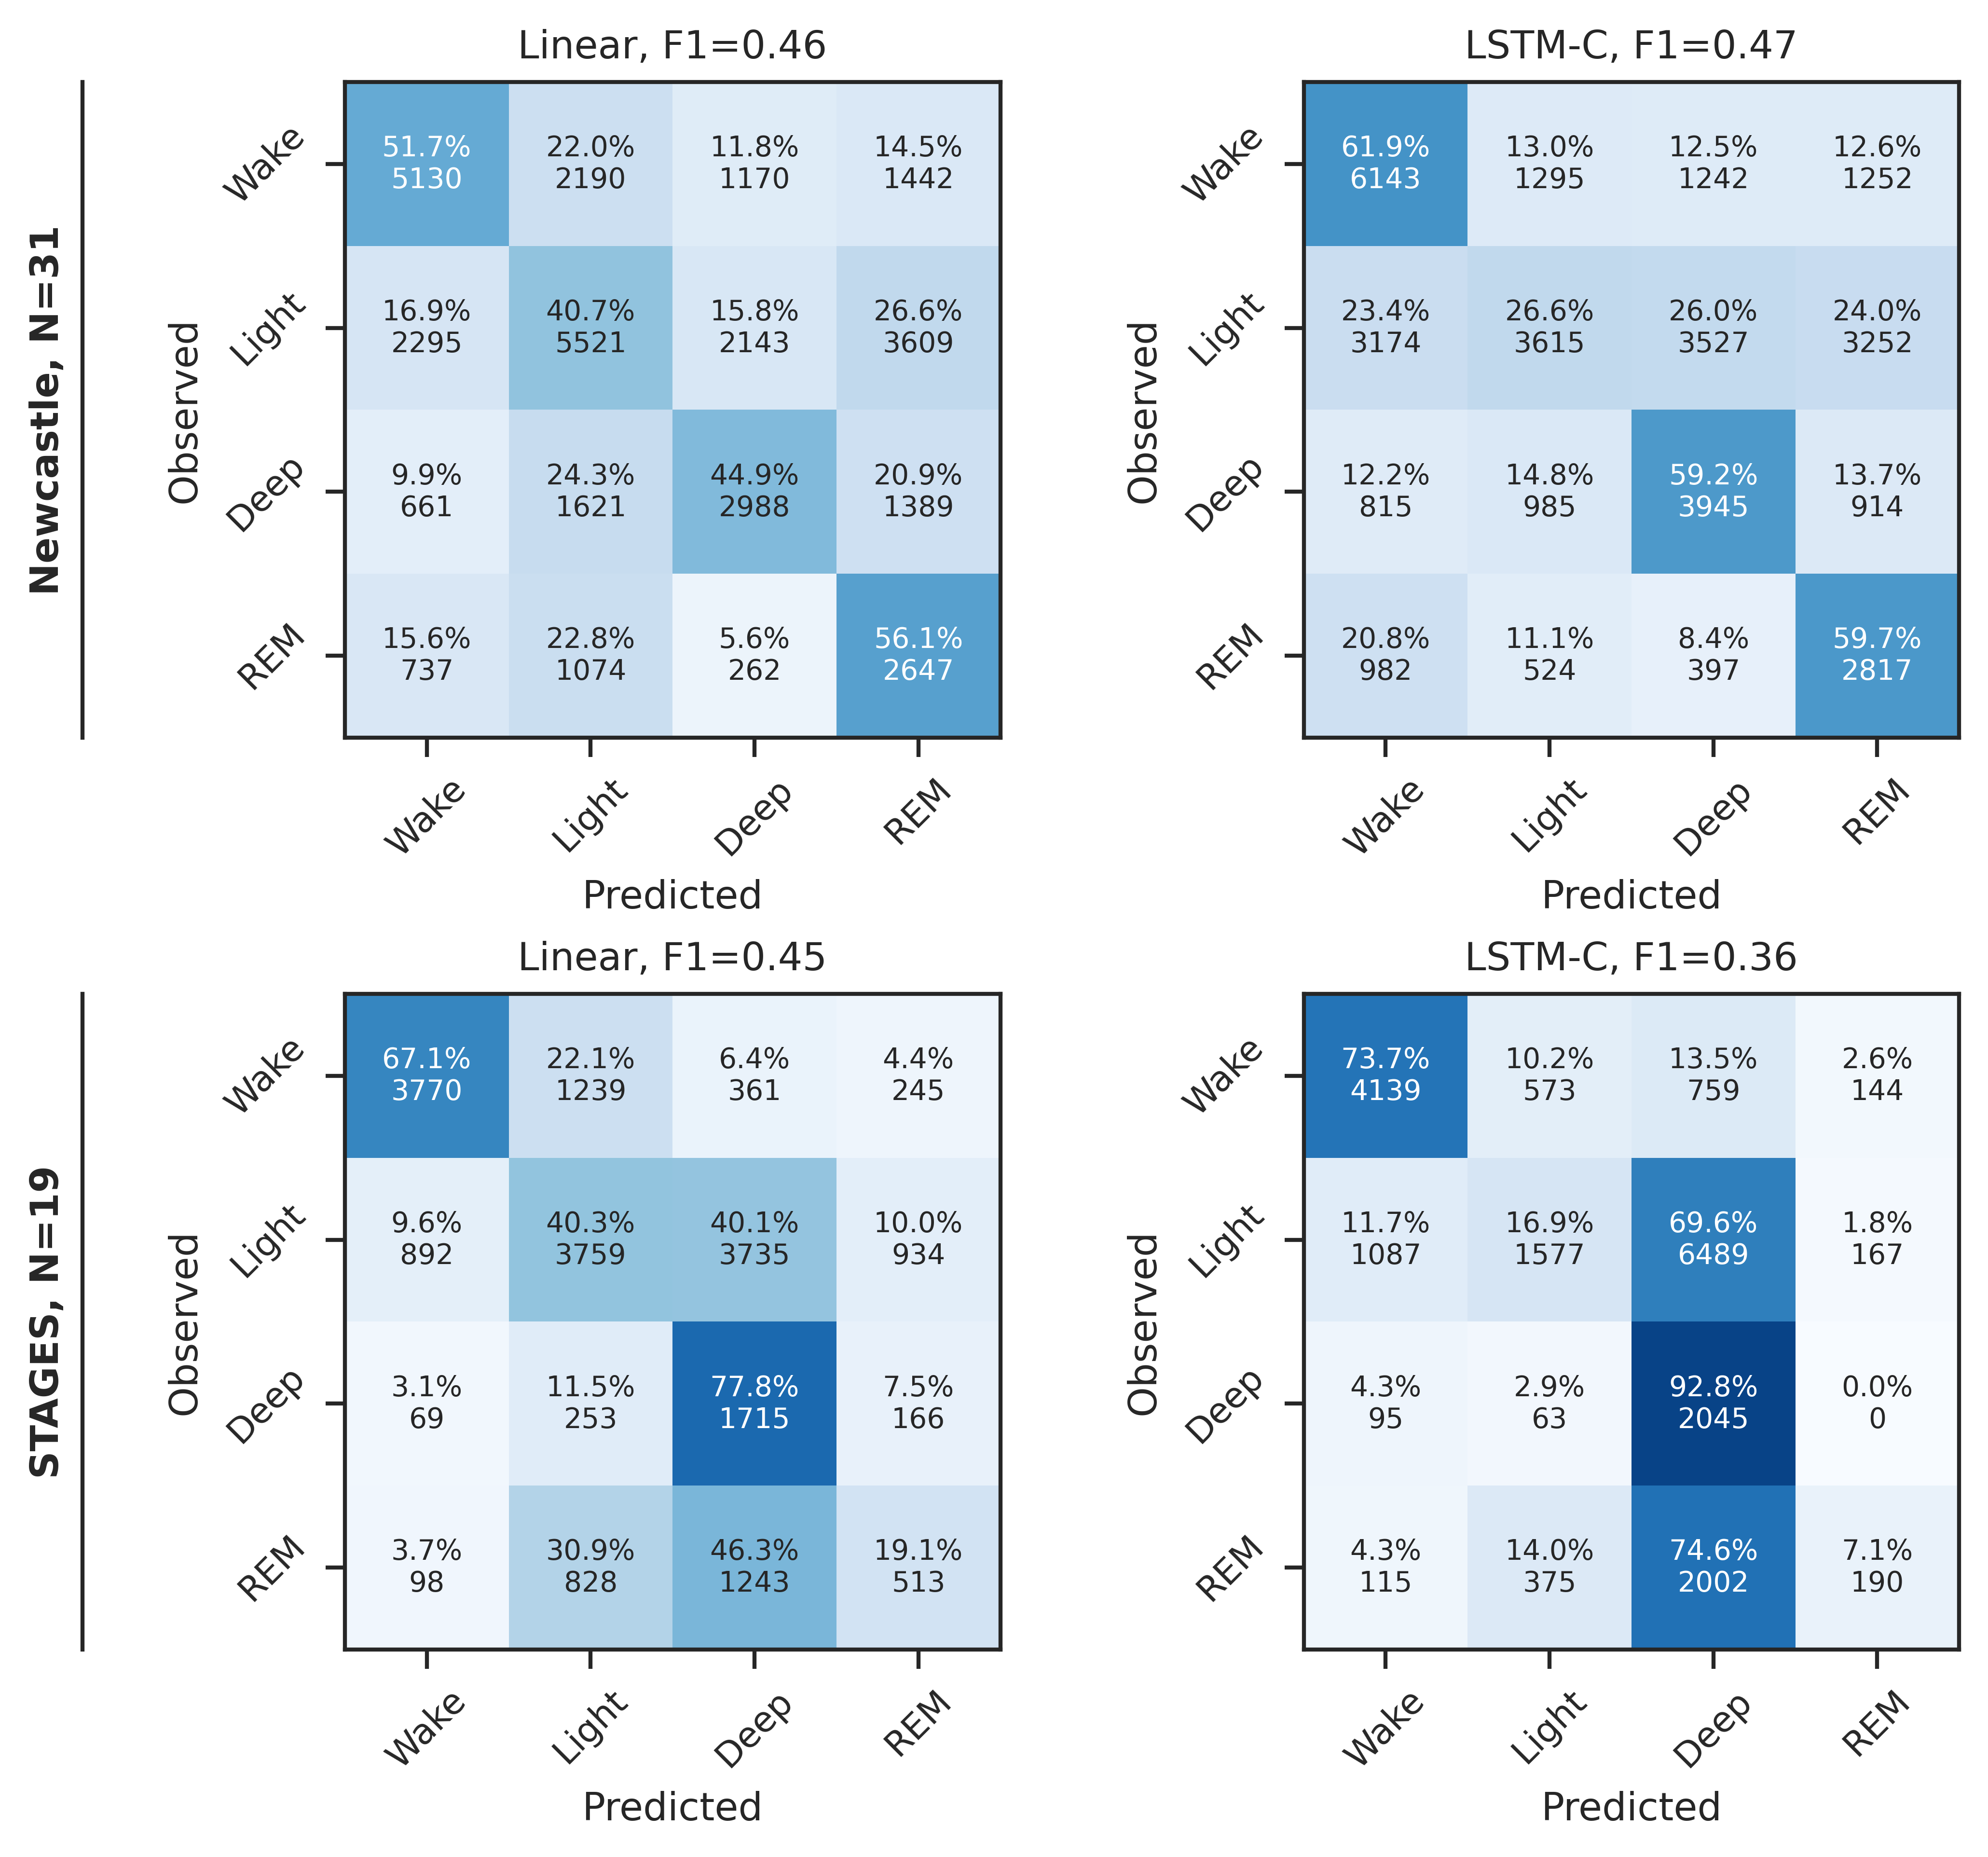

In [13]:
# Plot confusion mats
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

lin_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_dset = np.array(dataset_i)[np.array(exp_i) == 'Linear']
lin_dset[lin_dset == 'newcastle_left'] = 'newcastle'
lin_dset[lin_dset == 'newcastle_right'] = 'newcastle'
lstmc_dset = np.array(dataset_i)[np.array(exp_i) == 'LSTM-C']
lstmc_dset[lstmc_dset == 'newcastle_left'] = 'newcastle'
lstmc_dset[lstmc_dset == 'newcastle_right'] = 'newcastle'


lin_dict = {
    'title': 'Linear',
    'preds': lin_preds,
    'targets': lin_targets,
    'dset': lin_dset,
}
lstmc_dict = {
    'title': 'LSTM-C',
    'preds': lstmc_preds,
    'targets': lstmc_targets,
    'dset': lstmc_dset,
}

models = [lin_dict, lstmc_dict]

ss_label_names = ['Wake', 'Light', 'Deep', 'REM']
dset_order = ['Newcastle', 'STAGES']
dsets = ['newcastle','stages']
# dset_order = ['DREAMT', 'TBI']
# dsets = ['dreamt','tbi']
fig, axes_2d = plt.subplots(2,2, dpi=600, figsize=(7.1,6.3),layout='constrained')

for m, model in enumerate(models):
    axes = axes_2d[:,m].ravel()
    for i, dset in enumerate(dsets):
        preds = model['preds'][model['dset']==dset]
        preds = np.concatenate(list(preds))
        targets = model['targets'][model['dset']==dset]
        targets = np.concatenate(list(targets))

        # Epoch-by-epoch confusion matrix
        # Switch label orders 
        idx_dict = {}
        for place, tag in enumerate(ss_label_order):
            idx_dict[place] = (
                targets == ss_label_map[tag],
                preds == ss_label_map[tag],
            )
        for place, (label_idx, pred_idx) in idx_dict.items():
            targets[label_idx] = place
            preds[pred_idx] = place

        ## Confusion Matrix
        cm_abs = confusion_matrix(targets, preds, normalize=None)
        cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
        # Create combined annotation matrix
        annot = np.empty_like(cm_abs).astype(str)
        for r in range(cm_abs.shape[0]):
            for c in range(cm_abs.shape[1]):
                annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
        ax = sns.heatmap(
            cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes[i],
            square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
            xticklabels=ss_label_names, yticklabels=ss_label_names,# annot_kws={'fontsize':7}
        )
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.tick_params(rotation = 45)
        ax.set_ylabel('Observed')
        for label in ax.get_yticklabels():
            label.set_verticalalignment('center')
        ax.set_xlabel('Predicted')
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')

        if m == 0:
            sec = axes[i].secondary_yaxis(location=-0.4)
            sec.set_ylabel(f'{dset_order[i]}, N={sum(model['dset']==dset)}', fontweight='bold')
            sec.set_yticks([],[])
        
        ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')
plt.show()



In [ ]:
# Epoch by epoch ROC
fig, axes = plt.subplots(1, 2, dpi=600, figsize=(10,5), layout='constrained')
# Plot class_wise AUCS
cw_auc = roc_auc_score(targets_all, soft_preds_all, average=None, multi_class='ovr', labels=[0,1,2,3])
for k in range(soft_preds_all.shape[-1]):
    roc = roc_curve(targets_all, soft_preds_all[:,k], pos_label=k)
    axes[0].plot(roc[0], roc[1], label=f'{ss_label_map_inv[k]}, AUC={round(cw_auc[k],2)}')
axes[0].plot(roc[2], roc[2], ls='--',color='black')
axes[0].set_title('Epoch-by-epoch ROC curves')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

# Epoch-by-epoch confusion matrix
# Switch label orders 
idx_dict = {}
for place, tag in enumerate(ss_label_order):
    idx_dict[place] = (
        targets_all == ss_label_map[tag],
        preds_all == ss_label_map[tag],
    )
for place, (label_idx, pred_idx) in idx_dict.items():
    targets_all[label_idx] = place
    preds_all[pred_idx] = place

im = plot_confusion_matrix(
    targets_all,
    preds_all,
    axes[1],
    ss_label_order,
    # fontsize=fontsize,
    # colorbar=False,
)
axes[1].set_title('Epoch-by-epoch confusion')
ticks = np.arange(len(ss_label_order))
axes[1].set(
    xticks=ticks,
    yticks=ticks,
    xticklabels=ss_label_name,
    yticklabels=ss_label_name,
    xlabel='Predicted'
)
plt.show()